
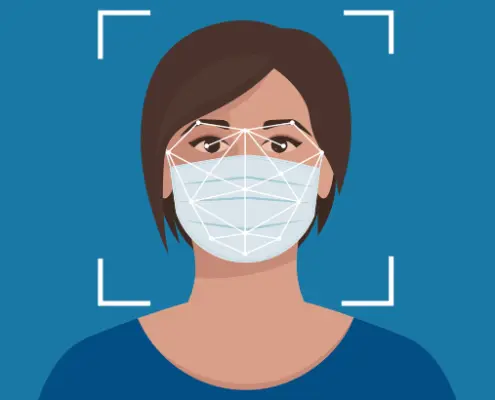


# 🎯 Project Objective
The objective of this project is to create a **binary image classification model** that predicts whether a face mask is present in an image or not.


Although the original dataset is designed for **object detection**, it is reformulated as an **image-level classification task** to simplify the pipeline and focus on training and deployment.

In [1]:
# importing libraries

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import xml.etree.ElementTree as tree
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings("ignore")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print("Path to dataset files:", path)

100%|██████████| 398M/398M [00:03<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1


# 📊 Dataset Description



*   Dataset: Facemask Detection
*   Image format: RGB images
*   Annotation format: Pascal VOC (i.e XML/Extensible Markup Language)
*   Task: Binary image classification

# Labels



*   1 --> mask present
*   0 --> mask not present




Each image receives a single label based on its annotations.





In [3]:
annotations = f'{path}/annotations'
images = f'{path}/images'

In [4]:
#list of all xml files in the annotations directory
xml_list = glob.glob(f'{annotations}/*.xml')

In [5]:
rows = []

for file in xml_list:
  root = tree.parse(file).getroot()
  filename = root.find('filename').text
  img = f'{images}/{filename}'

  labels = [obj.find('name').text.lower()for obj in root.findall("object")]
  label = 1 if "with_mask" in labels else 0

  rows.append([img,label])

In [6]:
df = pd.DataFrame(rows, columns=['image_path', 'label'])
print(df.head())

                                          image_path  label
0  /root/.cache/kagglehub/datasets/andrewmvd/face...      1
1  /root/.cache/kagglehub/datasets/andrewmvd/face...      1
2  /root/.cache/kagglehub/datasets/andrewmvd/face...      1
3  /root/.cache/kagglehub/datasets/andrewmvd/face...      1
4  /root/.cache/kagglehub/datasets/andrewmvd/face...      1


In [7]:
df.tail()

,image_path,label
848,/root/.cache/kagglehub/datasets/andrewmvd/face...,1
849,/root/.cache/kagglehub/datasets/andrewmvd/face...,0
850,/root/.cache/kagglehub/datasets/andrewmvd/face...,1
851,/root/.cache/kagglehub/datasets/andrewmvd/face...,1
852,/root/.cache/kagglehub/datasets/andrewmvd/face...,1


In [8]:
df.shape

(853, 2)

<Axes: xlabel='label', ylabel='count'>

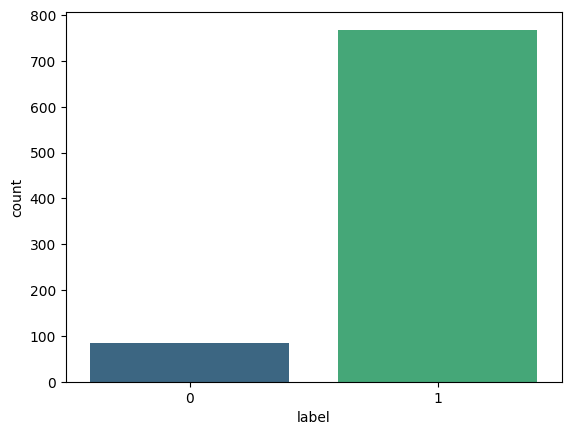

In [9]:
import seaborn as sns

sns.countplot(x='label', data=df, palette='viridis')
# In an interactive environment like Colab, this plot will display automatically.

#Data Preprocessing

The preprocessing pipeline includes:


*   Parsing XML annotations to generate image-level labels
*   Resizing images to 224 x 224
   List item
*  Converting images to tensors
*  Splitting dataset to training, testing and validation set using stratified sampling







In [10]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1])

weights = compute_class_weight(
    class_weight = "balanced",
    classes = classes,
    y = df['label'].values
)

class_weights = {0: weights[0], 1: weights[1]}
class_weights

{0: np.float64(5.017647058823529), 1: np.float64(0.5553385416666666)}

In [11]:
train_df, val_df = train_test_split(df, test_size = 0.2, stratify = df["label"], random_state = 42)

In [12]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
#if drop = True for both, it keeps the original indices as a new column. However, by keeping drop = True, it drops the old indices

In [13]:
counts = train_df["label"].value_counts().sort_index()
class_weights = counts.sum() / (2.0 * counts) #does element-wise division and assign the weights inversly proportional to their frequency
class_weights = torch.tensor(class_weights.values, dtype=torch.float)

# 🤖 Model Training

A **ResNet18** model pre-trained on ImageNet is used as the backbone.
The final fully connected layer (fc) is modified to output two classes.

Training configuration:

Loss function: CrossEntropyLoss with class weights
Optimizer: Adam
Metrics: Accuracy and F1-score

In [14]:
img_size = 224
batch_size = 32

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),])

val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),])

In [15]:
def load_images(df, tfms):
  xs = []
  ys = []

  for i in range(len(df)):
    img_path = df.loc[i, "image_path"]
    y = int(df.loc[i,'label'])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = tfms(img)

    xs.append(img)
    ys.append(y)

  x = torch.stack(xs)
  y = torch.tensor(ys, dtype=torch.long)


  return x,y

In [16]:
x_train, y_train = load_images(train_df, train_tfms)
x_val, y_val = load_images(val_df, val_tfms)

train_ds = torch.utils.data.TensorDataset(x_train, y_train)
val_ds = torch.utils.data.TensorDataset(x_val, y_val)

train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [17]:
device = 'cuda' if torch.cuda.is_available() else "cpu"

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight = class_weights.to (device))
optimizer = torch.optim.Adam(model.parameters(), lr= 3e-4)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


In [28]:
epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for x, y in train_dl:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    preds = []
    gts = []

    with torch.no_grad():
        for x, y in val_dl:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            p = torch.argmax(out, dim=1)

            preds.extend(p.cpu().numpy().tolist())
            gts.extend(y.cpu().numpy().tolist())

    acc = accuracy_score(gts, preds)
    f1 = f1_score(gts, preds)

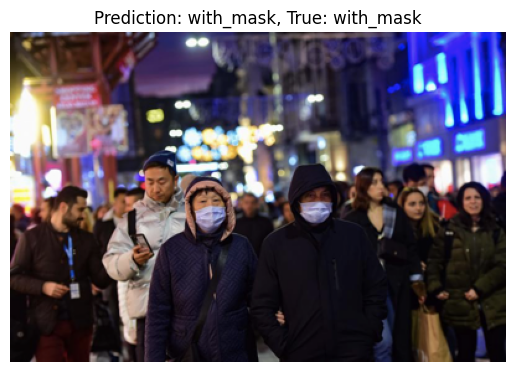

In [23]:
idx = np.random.randint(0, len(val_df))
img_path = val_df.loc[idx, "image_path"]
true_label = int(val_df.loc[idx, "label"])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = val_tfms(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    out = model(x)
    pred = int(torch.argmax(out, dim=1).item())

label_map = {0: "no_mask", 1: "with_mask"}
title_text = f"Prediction: {label_map[pred]}, True: {label_map[true_label]}"

plt.imshow(img)
plt.title(title_text)
plt.axis("off")
plt.show()

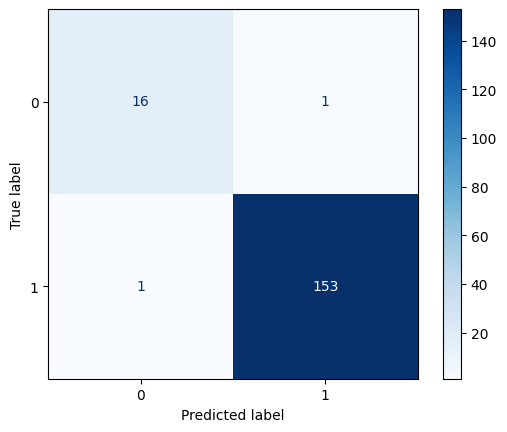

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(gts, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# 🏆 Result Comparison

Model performance is evaluated on the validation set.
Due to class imbalance, F1-score is considered the primary evaluation metric.

The confusion matrix shows that the model performs strongly on detecting masked faces while maintaining reasonable performance on the minority class.



In [25]:
model_path = "mask_cls_resnet18.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "img_size": img_size,
        "labels": {0: "no_mask", 1: "with_mask"},
    },
    model_path)

In [27]:
print(f"Final F1-score on the validation set: {f1:.4f}")

Final F1-score on the validation set: 0.9935
